<a href="https://colab.research.google.com/github/esma44raydemir-design/Yapay_Zeka_Projesi/blob/main/Yapay_zeka_projesi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv('/content/weather_classification_data.csv')
def ucus_izni(row):

    if row['Wind Speed'] < 30 and row['Weather Type'] in ['Sunny', 'Cloudy']:
        return 1 # Uçuş Onay
    else:
        return 0 # Uçuş Riskli

df['Ucus_Karari'] = df.apply(ucus_izni, axis=1)

print("\n--- Otomasyon Sonrası İlk 5 Satır ---")
print(df[['Weather Type', 'Wind Speed', 'Ucus_Karari']].head())





--- Otomasyon Sonrası İlk 5 Satır ---
  Weather Type  Wind Speed  Ucus_Karari
0        Rainy         9.5            0
1       Cloudy         8.5            1
2        Sunny         7.0            1
3        Sunny         1.5            1
4        Rainy        17.0            0


/tmp/ipykernel_13084/2712226093.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes['LeftTop'], x='Weather Type', y='Gorus_Mesafesi_km', data=df,
/tmp/ipykernel_13084/2712226093.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes['RightTop'], x='Ucus_Karari', data=df, palette="viridis", edgecolor=".2", linewidth=1)


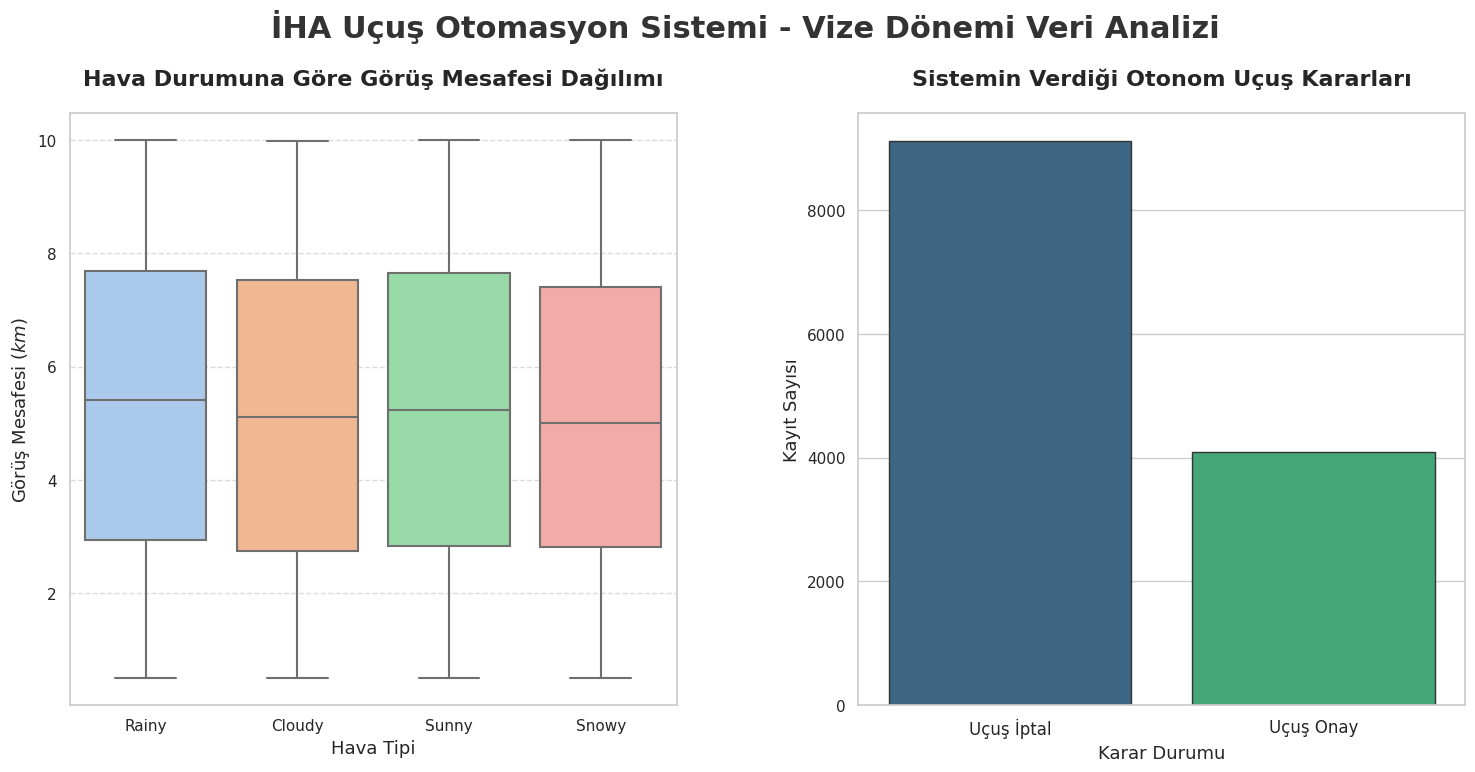

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('weather_classification_data.csv')

np.random.seed(42)
df['Gorus_Mesafesi_km'] = np.random.uniform(0.5, 10, size=len(df))
df['Pist_Trafik_Dolu'] = np.random.choice([0, 1], size=len(df), p=[0.8, 0.2])

def karar_ver(row):
    if row['Pist_Trafik_Dolu'] == 1 or row['Gorus_Mesafesi_km'] < 2.5 or row['Weather Type'] in ['Rainy', 'Snowy']:
        return 0 # İptal
    return 1 # Onay
df['Ucus_Karari'] = df.apply(karar_ver, axis=1)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
fig, axes = plt.subplot_mosaic([['LeftTop', 'RightTop']], figsize=(18, 8))
sns.boxplot(ax=axes['LeftTop'], x='Weather Type', y='Gorus_Mesafesi_km', data=df,
            linewidth=1.5, fliersize=3, palette="pastel")

axes['LeftTop'].set_title('Hava Durumuna Göre Görüş Mesafesi Dağılımı', fontsize=16, fontweight='bold', pad=20)
axes['LeftTop'].set_xlabel('Hava Tipi', fontsize=13, fontweight='medium')
axes['LeftTop'].set_ylabel('Görüş Mesafesi ($km$)', fontsize=13, fontweight='medium')
axes['LeftTop'].tick_params(labelsize=11)
axes['LeftTop'].grid(axis='y', linestyle='--', alpha=0.7)


sns.countplot(ax=axes['RightTop'], x='Ucus_Karari', data=df, palette="viridis", edgecolor=".2", linewidth=1)
axes['RightTop'].set_title('Sistemin Verdiği Otonom Uçuş Kararları', fontsize=16, fontweight='bold', pad=20)
axes['RightTop'].set_xlabel('Karar Durumu', fontsize=13, fontweight='medium')
axes['RightTop'].set_ylabel('Kayıt Sayısı', fontsize=13, fontweight='medium')
axes['RightTop'].set_xticks([0, 1])
axes['RightTop'].set_xticklabels(['Uçuş İptal', 'Uçuş Onay'], fontsize=12)
axes['RightTop'].tick_params(axis='y', labelsize=11)

plt.subplots_adjust(wspace=0.3, top=0.85)
fig.suptitle('İHA Uçuş Otomasyon Sistemi - Vize Dönemi Veri Analizi', fontsize=22, fontweight='bold', color='#333')

plt.show()